In [11]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

# load the pdspl_samples object with pickle
with open('../../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

In [14]:
import numpy as np
import pandas as pd
from scipy import spatial
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import corner
from tqdm import tqdm

# =============================================================================
# 1. GENERAL UTILITIES (Math & Pairing)
# =============================================================================
def normalize_features(data, norm_type='zscore', data_min=None, data_max=None):
    """Normalizes a 1D array of data."""
    data = np.array(data, dtype=float)
    if norm_type == 'minmax':
        d_min = data_min if data_min is not None else np.nanmin(data)
        d_max = data_max if data_max is not None else np.nanmax(data)
        if d_max == d_min: return np.zeros_like(data)
        return (data - d_min) / (d_max - d_min)
    elif norm_type == 'zscore':
        std = np.nanstd(data)
        if std == 0: return np.zeros_like(data)
        return (data - np.nanmean(data)) / std
    else:
        raise ValueError("Unsupported normalization type.")

def get_unique_kdtree_pairs(points):
    """Finds uniquely paired nearest neighbors in n-dimensional space."""
    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=2)
    
    neighbor_distances = distances[:, 1]
    neighbor_indices = indices[:, 1]
    
    n_samples = points.shape[0]
    all_pairs = np.column_stack((np.arange(n_samples), neighbor_indices))
    all_pairs.sort(axis=1)
    
    unique_pairs, unique_idxs = np.unique(all_pairs, axis=0, return_index=True)
    return unique_pairs, neighbor_distances[unique_idxs]

def add_dissimilarity_parameter(pairs_table, dissimilarity_keys, col_name='dissimilarity'):
    """Computes RMS dissimilarity across specified columns."""
    diffs = np.array([pairs_table[key] for key in dissimilarity_keys])
    pairs_table[col_name] = np.sqrt(np.mean(diffs**2, axis=0))
    return pairs_table

# =============================================================================
# 2. PDSPL SPECIFIC PHYSICS & TABLES
# =============================================================================
def beta_double_source_plane(z_lens, z_source_1, z_source_2, cosmo):
    ds1 = cosmo.angular_diameter_distance(z_source_1).value
    dds1 = cosmo.angular_diameter_distance_z1z2(z_lens, z_source_1).value
    ds2 = cosmo.angular_diameter_distance(z_source_2).value
    dds2 = cosmo.angular_diameter_distance_z1z2(z_lens, z_source_2).value
    return dds1 / ds1 * ds2 / dds2

def beta2theta_e_ratio(beta_dsp, gamma_pl=2, lambda_mst=1):
    return (beta_dsp - (1 - lambda_mst) * (1 - beta_dsp)) ** (1 / (gamma_pl - 1))

def get_pairs_table_PDSPL(data_table, pair_indices, cosmo):
    """
    Vectorized version of the PDSPL pairs table builder.
    """
    # 1. Extract indices as arrays
    idx1 = pair_indices[:, 0]
    idx2 = pair_indices[:, 1]
    
    # 2. Enforce z_S1 < z_S2 vectorially
    # We use .data to get the underlying numpy arrays for maximum speed
    z_S_arr = data_table['z_S'].data if hasattr(data_table['z_S'], 'data') else np.array(data_table['z_S'])
    swap_mask = z_S_arr[idx1] > z_S_arr[idx2]
    
    # Where mask is True, swap the indices
    idx1_final = np.where(swap_mask, idx2, idx1)
    idx2_final = np.where(swap_mask, idx1, idx2)
    
    # 3. Initialize dictionary to build the table
    pairs_dict = {
        "index_1": idx1_final,
        "index_2": idx2_final,
    }
    
    # Helper function for fast array extraction
    def get_vals(colname):
        arr = data_table[colname].data if hasattr(data_table[colname], 'data') else np.array(data_table[colname])
        return arr[idx1_final], arr[idx2_final]

    # 4. Extract standard parameters
    pairs_dict['z_S1'], pairs_dict['z_S2'] = get_vals('z_S')
    
    z_D1, z_D2 = get_vals('z_D')
    pairs_dict['z_D1'], pairs_dict['z_D2'] = z_D1, z_D2
    pairs_dict['z_D'] = 0.5 * (z_D1 + z_D2)
    
    pairs_dict['theta_E1'], pairs_dict['theta_E2'] = get_vals('theta_E')
    pairs_dict['sigma_v_D1'], pairs_dict['sigma_v_D2'] = get_vals('sigma_v_D')
    pairs_dict['R_e_kpc_D1'], pairs_dict['R_e_kpc_D2'] = get_vals('R_e_kpc')
    pairs_dict['R_e_arcsec_D1'], pairs_dict['R_e_arcsec_D2'] = get_vals('R_e_arcsec')
    pairs_dict['Sigma_half_Msun/pc2_D1'], pairs_dict['Sigma_half_Msun/pc2_D2'] = get_vals('Sigma_half_Msun/pc2')
    pairs_dict['gamma_pl_1'], pairs_dict['gamma_pl_2'] = get_vals('gamma_pl')
    
    pairs_dict['beta_E_pseudo'] = pairs_dict['theta_E1'] / pairs_dict['theta_E2']
    
    # 5. Extract errors if they exist
    for err_col in ['err_z_D', 'err_sigma_v_D', 'err_R_e_arcsec']:
        if err_col in data_table.colnames:
            pairs_dict[f'{err_col}1'], pairs_dict[f'{err_col}2'] = get_vals(err_col)
            
    # 6. Calculate Beta DSPL 
    # NOTE: This assumes your custom functions can accept numpy arrays (which they should 
    # if using standard astropy.cosmology tools).
    _beta_E_DSPL_D1 = beta_double_source_plane(z_lens=z_D1, z_source_1=pairs_dict['z_S1'], z_source_2=pairs_dict['z_S2'], cosmo=cosmo)
    _beta_E_DSPL_D2 = beta_double_source_plane(z_lens=z_D2, z_source_1=pairs_dict['z_S1'], z_source_2=pairs_dict['z_S2'], cosmo=cosmo)
    
    beta_E_DSPL_D1 = beta2theta_e_ratio(_beta_E_DSPL_D1, gamma_pl=pairs_dict['gamma_pl_1'], lambda_mst=1)
    beta_E_DSPL_D2 = beta2theta_e_ratio(_beta_E_DSPL_D2, gamma_pl=pairs_dict['gamma_pl_2'], lambda_mst=1)
    
    pairs_dict['beta_E_DSPL'] = 0.5 * (beta_E_DSPL_D1 + beta_E_DSPL_D2)
    pairs_dict['rel_diff_beta_E'] = 1 - (pairs_dict['beta_E_pseudo'] / pairs_dict['beta_E_DSPL'])

    # 7. Extract Magnitudes, Colors, and compute their relative differences
    for band in ['g', 'r', 'i']:
        col_name = f'mag_D_{band}'
        if col_name in data_table.colnames:
            m1, m2 = get_vals(col_name)
            pairs_dict[f'{col_name}_1'] = m1
            pairs_dict[f'{col_name}_2'] = m2
            # Dynamically calculate rel_diff for all available bands to prevent KeyErrors
            pairs_dict[f'rel_diff_{col_name}'] = 2 * (m2 - m1) / (m2 + m1)

    # Calculate colors and their differences
    if 'mag_D_g_1' in pairs_dict and 'mag_D_r_1' in pairs_dict:
        pairs_dict['color_D_gr_1'] = pairs_dict['mag_D_g_1'] - pairs_dict['mag_D_r_1']
        pairs_dict['color_D_gr_2'] = pairs_dict['mag_D_g_2'] - pairs_dict['mag_D_r_2']
        pairs_dict['rel_diff_color_D_gr'] = 2 * (pairs_dict['color_D_gr_2'] - pairs_dict['color_D_gr_1']) / (pairs_dict['color_D_gr_2'] + pairs_dict['color_D_gr_1'])

    if 'mag_D_r_1' in pairs_dict and 'mag_D_i_1' in pairs_dict:
        pairs_dict['color_D_ri_1'] = pairs_dict['mag_D_r_1'] - pairs_dict['mag_D_i_1']
        pairs_dict['color_D_ri_2'] = pairs_dict['mag_D_r_2'] - pairs_dict['mag_D_i_2']
        pairs_dict['rel_diff_color_D_ri'] = 2 * (pairs_dict['color_D_ri_2'] - pairs_dict['color_D_ri_1']) / (pairs_dict['color_D_ri_2'] + pairs_dict['color_D_ri_1'])

    # 8. Compute all other relative differences
    pairs_dict["rel_diff_sigma_v_D"] = 2 * (pairs_dict['sigma_v_D2'] - pairs_dict['sigma_v_D1']) / (pairs_dict['sigma_v_D2'] + pairs_dict['sigma_v_D1'])
    pairs_dict["rel_diff_R_e_kpc"] = 2 * (pairs_dict['R_e_kpc_D2'] - pairs_dict['R_e_kpc_D1']) / (pairs_dict['R_e_kpc_D2'] + pairs_dict['R_e_kpc_D1'])
    pairs_dict["rel_diff_R_e_arcsec"] = 2 * (pairs_dict['R_e_arcsec_D2'] - pairs_dict['R_e_arcsec_D1']) / (pairs_dict['R_e_arcsec_D2'] + pairs_dict['R_e_arcsec_D1'])
    pairs_dict["rel_diff_Sigma_half"] = 2 * (pairs_dict['Sigma_half_Msun/pc2_D2'] - pairs_dict['Sigma_half_Msun/pc2_D1']) / (pairs_dict['Sigma_half_Msun/pc2_D2'] + pairs_dict['Sigma_half_Msun/pc2_D1'])
    pairs_dict["rel_diff_z_D"] = 2 * (pairs_dict['z_D2'] - pairs_dict['z_D1']) / (pairs_dict['z_D2'] + pairs_dict['z_D1'])
    pairs_dict["rel_diff_gamma_pl"] = 2 * (pairs_dict['gamma_pl_2'] - pairs_dict['gamma_pl_1']) / (pairs_dict['gamma_pl_2'] + pairs_dict['gamma_pl_1'])

    return Table(pairs_dict)

# =============================================================================
# 3. PIPELINE ORCHESTRATION (Errors & MC Loop)
# =============================================================================

def add_dissimilarity_parameter(pairs_table, dissimilarity_keys, col_name='dissimilarity'):
    """
    Computes the RMS dissimilarity across specified columns and appends 
    it as a new column to the pairs table.
    
    Parameters:
    -----------
    pairs_table : astropy.table.Table or pandas.DataFrame
        The table containing the paired data and relative difference columns.
    dissimilarity_keys : list of str
        The column names to use for calculating the dissimilarity.
    col_name : str, optional
        The name of the new column to be added. Default is 'dissimilarity'.
        
    Returns:
    --------
    pairs_table : astropy.table.Table or pandas.DataFrame
        The original table with the new dissimilarity column appended.
    """
    # Extract the relevant columns into a 2D numpy array. 
    # The resulting shape is (number_of_keys, number_of_pairs).
    diffs = np.array([pairs_table[key] for key in dissimilarity_keys])
    
    # Calculate the Root Mean Square (RMS) across the keys (axis=0)
    # Formula: sqrt( mean( diff^2 ) )
    dissimilarity_estimator = np.sqrt(np.mean(diffs**2, axis=0))
    
    # Append the computed parameter to the table
    pairs_table[col_name] = dissimilarity_estimator
    
    return pairs_table

def match_and_build_PDSPL_pairs(data_table, pairing_keys, cosmo, norm_type='zscore', dissimilarity_keys=None):
    """
    Main orchestrator function: Normalizes features, finds unique pairs using a KD-Tree, 
    and builds the PDSPL paired table with derived lensing quantities.
    
    Parameters:
    -----------
    data_table : astropy.table.Table
        The input data containing lens and source properties.
    pairing_keys : list of str
        Columns to base the KD-tree matching on (e.g., mass, redshift, velocity dispersion).
    cosmo : astropy.cosmology.Cosmology
        The cosmology to use for lens distance calculations.
    norm_type : str, optional
        Normalization method: 'zscore' or 'minmax'. Default is 'zscore'.
        
    Returns:
    --------
    pdspl_paired_table : astropy.table.Table
        A table of uniquely paired rows with calculated PDSPL properties.
    """
    # 1. Extract and normalize the feature space based on the requested keys
    normalized_features = []
    for key in pairing_keys:
        normalized_features.append(normalize_features(data_table[key], norm_type=norm_type))
        
    points = np.stack(normalized_features, axis=1)
    
    # 2. Find unique nearest-neighbor pairs in the normalized N-dimensional space
    unique_pairs, pair_distances = get_unique_kdtree_pairs(points)
    
    # 3. Build the final paired table using your specific PDSPL logic
    pdspl_paired_table = get_pairs_table_PDSPL(
        data_table=data_table, 
        pair_indices=unique_pairs, 
        cosmo=cosmo,
    )
    
    # 4. Optional but recommended: Add the N-dimensional KD-Tree distance 
    # to the final table so you can filter out poor matches later if needed.
    pdspl_paired_table['kd_tree_distance'] = pair_distances

    # 5. Compute a composite dissimilarity parameter based on the relative differences
    # in the key properties. This can be used to filter pairs later or as a feature in analysis.
    dissimilarity_keys = dissimilarity_keys if dissimilarity_keys is not None else [f'rel_diff_{key}' for key in pairing_keys]
    pdspl_paired_table = add_dissimilarity_parameter(pdspl_paired_table, dissimilarity_keys, col_name='dissimilarity')
    
    return pdspl_paired_table

def inject_observational_errors(table, error_config):
    """Dynamically applies errors based on notebook dictionary configuration.
    Example error_config: {
        'z_photo_err_frac': 0.05,  # 5% error on z_D
        'sigma_v_err': 20,         # 20 km/s error on sigma_v_D
        'R_e_err_frac': 0.1        # 10% error on R_e_arcsec
    }
    
    """
    tbl = table.copy()
    if 'z_photo_err_frac' in error_config:
        tbl['z_D'] += np.random.normal(0, error_config['z_photo_err_frac'] * (1 + tbl['z_D']))
    elif 'z_spec_err' in error_config:
        tbl['z_D'] += np.random.normal(0, error_config['z_spec_err'], len(tbl))
        
    if 'sigma_v_err' in error_config:
        tbl['sigma_v_D'] += np.random.normal(0, error_config['sigma_v_err'], len(tbl))
        
    if 'R_e_err_frac' in error_config:
        tbl['R_e_arcsec'] += np.random.normal(0, error_config['R_e_err_frac'] * tbl['R_e_arcsec'])
    return tbl

def compute_binned_beta_scatter(pairs_table, num_bins=10, dissim_threshold=0.1):
    """Bins scatter statistics dynamically."""
    dissim = np.array(pairs_table['dissimilarity'])
    delta_beta = np.array(pairs_table['rel_diff_beta_E'])
    
    mask = np.isfinite(dissim) & np.isfinite(delta_beta)
    if dissim_threshold is not None: mask &= (dissim < dissim_threshold)
        
    v_dissim, v_delta = dissim[mask], delta_beta[mask]
    if len(v_dissim) == 0: return [], []
    
    bin_edges = np.percentile(v_dissim, np.linspace(0, 100, num_bins + 1))
    bin_edges[0] -= 1e-8
    bin_edges[-1] += 1e-8
    
    digitized = np.digitize(v_dissim, bin_edges)
    binned_mean, binned_scatter = [], []
    
    for i in range(1, len(bin_edges)):
        b_mask = (digitized == i)
        if np.sum(b_mask) > 1:
            binned_mean.append(np.mean(v_dissim[b_mask]))
            binned_scatter.append(np.std(v_delta[b_mask], ddof=1))
        else:
            binned_mean.append(np.nan)
            binned_scatter.append(np.nan)
            
    return binned_mean, binned_scatter

def run_mc_analysis(table, cosmo, pairing_keys, dissim_keys, error_config, N_realizations=100, desc="MC Loop"):
    """Main Orchestrator. Handles everything from a single notebook call."""
    if len(table) < 2: return None
        
    all_dissim, all_scatter = [], []
    last_tbl_clean, last_tbl_err = None, None

    for _ in tqdm(range(N_realizations), desc=desc):
        noisy_table = inject_observational_errors(table, error_config)
        
        points = np.stack([normalize_features(noisy_table[pk]) for pk in pairing_keys], axis=1)
        unique_pairs, _ = get_unique_kdtree_pairs(points)
        
        tbl_clean = get_pairs_table_PDSPL(table, unique_pairs, cosmo)
        tbl_err = get_pairs_table_PDSPL(noisy_table, unique_pairs, cosmo)
        
        tbl_err = add_dissimilarity_parameter(tbl_err, dissim_keys)
        
        b_mean, b_scat = compute_binned_beta_scatter(tbl_err, num_bins=10, dissim_threshold=0.1)
        all_dissim.append(b_mean)
        all_scatter.append(b_scat)
        
        last_tbl_clean, last_tbl_err = tbl_clean, tbl_err

    return {
        "binned_dissim": np.array(all_dissim),
        "binned_scatter": np.array(all_scatter),
        "last_tbl_clean": last_tbl_clean,
        "last_tbl_err": last_tbl_err,
        "raw_lenses": len(table),
        "raw_pairs": len(last_tbl_clean)
    }

# =============================================================================
# 4. PLOTTING
# =============================================================================
def plot_mc_results(mc_dict, save_path=None):
    """Takes a dictionary of configured MC outputs and plots them."""
    fig = plt.figure(figsize=(13, 6))
    gs = GridSpec(4, 9, figure=fig, wspace=-0.02, hspace=-0.02)
    ax_scatter = fig.add_subplot(gs[1:, 0:3])
    ax_fit = fig.add_subplot(gs[1:, 5:9])
    
    for label, config in mc_dict.items():
        res = config['results']
        if res is None: continue
        
        color = config.get('color', 'black')
        marker = config.get('marker', 'o')
        
        tbl_err, tbl_clean = res['last_tbl_err'], res['last_tbl_clean']
        dissim = tbl_err['dissimilarity']
        delta_beta = 1 - tbl_clean['beta_E_pseudo'] / tbl_clean['beta_E_DSPL']
        mask = (dissim < 0.1) & np.isfinite(delta_beta)
        
        ax_scatter.scatter(dissim[mask], delta_beta[mask], color=color, alpha=0.01, s=10)
        
        mean_dissim = np.nanmean(res['binned_dissim'], axis=0)
        mean_scatter = np.nanmean(res['binned_scatter'], axis=0)
        std_scatter = np.nanstd(res['binned_scatter'], axis=0)
        
        valid = np.isfinite(mean_dissim) & np.isfinite(mean_scatter)
        if np.sum(valid) > 2:
            x, y, yerr = mean_dissim[valid], mean_scatter[valid], std_scatter[valid]
            weights = np.where(yerr > 0, 1.0 / yerr, 0.0)
            coeffs, cov = np.polyfit(x, y, 1, w=weights, cov=True)
            
            fit_lbl = r"%s: $y = (%.2f \pm %.2f) x + (%.3f \pm %.3f)$" % (label, coeffs[0], np.sqrt(cov[0,0]), coeffs[1], np.sqrt(cov[1,1]))
            ax_fit.plot(x, np.polyval(coeffs, x), '--', color=color, label=fit_lbl)
            ax_fit.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)
            ax_fit.scatter(x, y, marker=marker, color=color)
            
            res['fit_coeffs'] = coeffs
            res['fit_cov'] = cov

    ax_scatter.set(xlabel=r"$\mathcal{D}_{\rm deflector}$", ylabel=r"$\Delta \beta_{E} / \beta_{E}$", xlim=(0, 0.09), ylim=(-0.43, 0.43))
    ax_fit.set(xlabel=r"$\mathcal{D}_{\rm deflector}$", ylabel=r"$\sigma_{\beta_{\rm E}}$", xlim=(0, 0.06), ylim=(0, 0.22))
    ax_fit.legend(frameon=True)
    
    if save_path: fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig

In [16]:
from astropy.cosmology import FlatLambdaCDM

cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

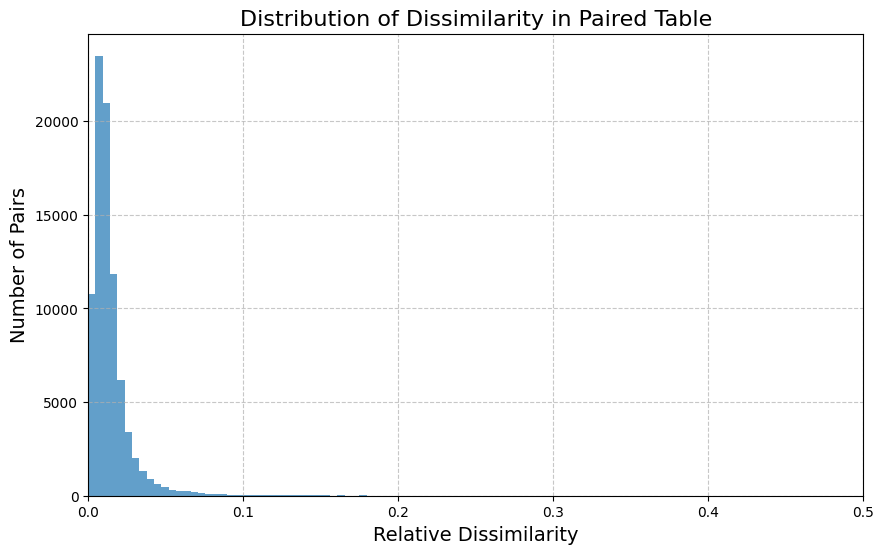

(0.0, 0.1)

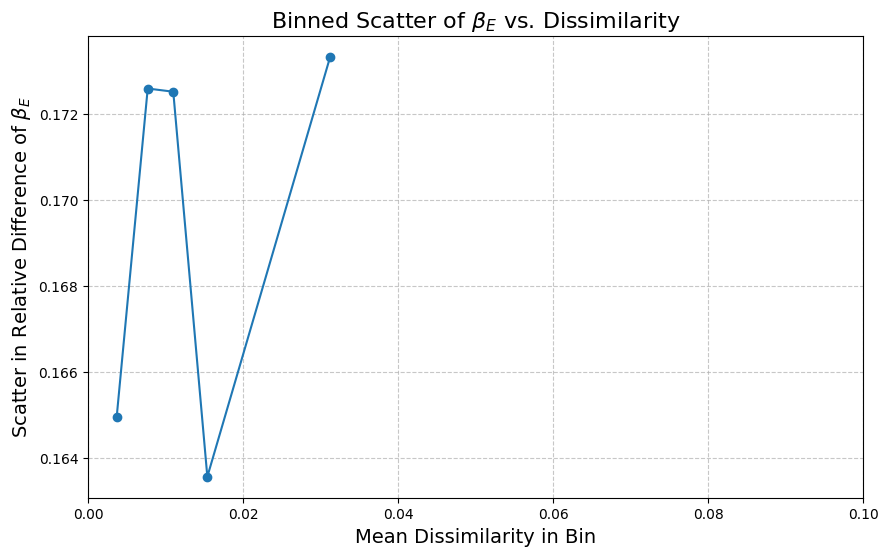

In [19]:
test_table = pdspl_samples['lsst_y10']['table']

# add 1 millimag error to the magnitudes to prevent exact duplicates in the feature space
for band in ['g', 'r', 'i']:
    test_table[f'mag_D_{band}'] += np.random.normal(loc=0.0, scale=0.001, size=len(test_table))

new_pairs_table = match_and_build_PDSPL_pairs(test_table, 
                                    pairing_keys=['mag_D_g', 'mag_D_r', 'mag_D_i', 'R_e_arcsec', 'z_D'], 
                                    dissimilarity_keys=['rel_diff_mag_D_g', 'rel_diff_mag_D_r', 'rel_diff_mag_D_i', 'rel_diff_R_e_arcsec', 'rel_diff_z_D'],
                                    norm_type='zscore', cosmo=cosmo_true)


plt.figure(figsize=(10, 6))
plt.hist(
    new_pairs_table['dissimilarity'],
    bins=100, alpha=0.7)
plt.xlabel('Relative Dissimilarity', fontsize=14)
plt.ylabel('Number of Pairs', fontsize=14)
plt.title('Distribution of Dissimilarity in Paired Table', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5)
plt.show()

binned_results = compute_binned_beta_scatter(new_pairs_table, num_bins=5, dissim_threshold=0.1)

plt.figure(figsize=(10, 6))
plt.plot(binned_results[0], binned_results[1], marker='o', linestyle='-', markersize=6)
plt.xlabel('Mean Dissimilarity in Bin', fontsize=14)
plt.ylabel('Scatter in Relative Difference of $\\beta_E$', fontsize=14)
plt.title('Binned Scatter of $\\beta_E$ vs. Dissimilarity', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.1)

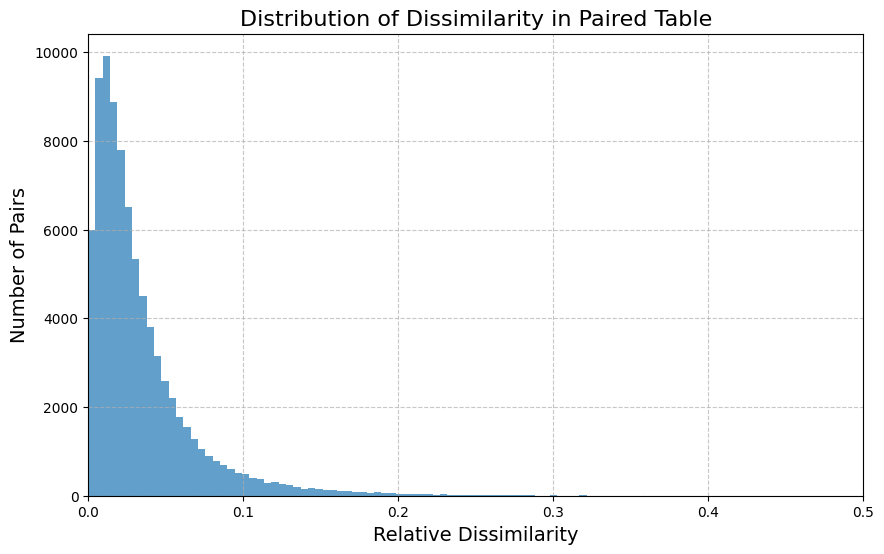

In [20]:
test_table = pdspl_samples['lsst_y10']['table']

# add 1 millimag error to the magnitudes to prevent exact duplicates in the feature space
for band in ['g', 'r', 'i']:
    test_table[f'mag_D_{band}'] += np.random.normal(loc=0.0, scale=0.001, size=len(test_table))

new_pairs_table = match_and_build_PDSPL_pairs(test_table, 
                                    pairing_keys=['mag_D_g', 'mag_D_r', 'mag_D_i', 'R_e_arcsec'], 
                                    dissimilarity_keys=['rel_diff_mag_D_g', 'rel_diff_mag_D_r', 'rel_diff_mag_D_i', 'rel_diff_R_e_arcsec', 'rel_diff_z_D'],
                                    norm_type='zscore', cosmo=cosmo_true)


plt.figure(figsize=(10, 6))
plt.hist(
    new_pairs_table['dissimilarity'],
    bins=100, alpha=0.7)
plt.xlabel('Relative Dissimilarity', fontsize=14)
plt.ylabel('Number of Pairs', fontsize=14)
plt.title('Distribution of Dissimilarity in Paired Table', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5)
plt.show()

